# Base Model

In [24]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from itertools import combinations

from sklearn.model_selection import StratifiedKFold 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostClassifier, CatBoostRegressor
import xgboost as xgb


# =========================================================
# 1. 경로 설정
# =========================================================
BASE_PATH = r"C:\Users\user\Downloads\sas-viya_competition\train"
SAVE_PATH = r"C:\Users\user\Downloads\sas-viya_competition\output"

CUSTOMER_PATH = os.path.join(BASE_PATH, "train_customer_info.csv")
FINANCE_PATH = os.path.join(BASE_PATH, "train_finance_profile.csv")
TARGET_PATH = os.path.join(BASE_PATH, "train_targets.csv")
TXN_PATH = os.path.join(BASE_PATH, "train_transaction_history.csv")


# =========================================================
# 2. 데이터 로드
# =========================================================
customer = pd.read_csv(CUSTOMER_PATH)
finance = pd.read_csv(FINANCE_PATH)
targets = pd.read_csv(TARGET_PATH)
txn = pd.read_csv(TXN_PATH)

print("customer shape :", customer.shape)
print("finance shape  :", finance.shape)
print("targets shape  :", targets.shape)
print("txn shape      :", txn.shape)


# =========================================================
# 3. 날짜형 변환
# =========================================================
customer["join_date"] = pd.to_datetime(customer["join_date"])
txn["trans_date"] = pd.to_datetime(txn["trans_date"])


# =========================================================
# 4. Transaction Feature Engineering
# =========================================================
def build_transaction_features(txn_df: pd.DataFrame) -> pd.DataFrame:
    df = txn_df.copy()

    ref_date = df["trans_date"].max() + pd.Timedelta(days=1)
    df = df.sort_values(["customer_id", "trans_date"])

    df["trans_year_month"] = df["trans_date"].dt.to_period("M").astype(str)

    basic_agg = df.groupby("customer_id").agg(
        txn_count=("trans_id", "count"),
        txn_amount_sum=("trans_amount", "sum"),
        txn_amount_mean=("trans_amount", "mean"),
        txn_amount_std=("trans_amount", "std"),
        txn_amount_min=("trans_amount", "min"),
        txn_amount_max=("trans_amount", "max"),
        installment_ratio=("is_installment", "mean"),
        last_txn_date=("trans_date", "max"),
        first_txn_date=("trans_date", "min"),
        biz_type_nunique=("biz_type", "nunique"),
        item_category_nunique=("item_category", "nunique"),
    ).reset_index()

    basic_agg["recency_days"] = (ref_date - basic_agg["last_txn_date"]).dt.days
    basic_agg["customer_active_days"] = (
        basic_agg["last_txn_date"] - basic_agg["first_txn_date"]
    ).dt.days.clip(lower=1)

    basic_agg["txn_per_active_day"] = (
        basic_agg["txn_count"] / basic_agg["customer_active_days"]
    )
    basic_agg["amount_per_active_day"] = (
        basic_agg["txn_amount_sum"] / basic_agg["customer_active_days"]
    )

    df["prev_trans_date"] = df.groupby("customer_id")["trans_date"].shift(1)
    df["gap_days"] = (df["trans_date"] - df["prev_trans_date"]).dt.days

    gap_agg = df.groupby("customer_id").agg(
        avg_gap_days=("gap_days", "mean"),
        std_gap_days=("gap_days", "std"),
    ).reset_index()

    biz_pivot = (
        pd.crosstab(df["customer_id"], df["biz_type"], normalize="index")
        .add_prefix("biz_ratio_")
        .reset_index()
    )

    cat_pivot = (
        pd.crosstab(df["customer_id"], df["item_category"], normalize="index")
        .add_prefix("cat_ratio_")
        .reset_index()
    )

    monthly = df.groupby(["customer_id", "trans_year_month"]).agg(
        monthly_amount=("trans_amount", "sum"),
        monthly_count=("trans_id", "count")
    ).reset_index()

    monthly_agg = monthly.groupby("customer_id").agg(
        monthly_amount_mean=("monthly_amount", "mean"),
        monthly_amount_std=("monthly_amount", "std"),
        monthly_count_mean=("monthly_count", "mean"),
        monthly_count_std=("monthly_count", "std"),
        active_months=("trans_year_month", "nunique"),
    ).reset_index()

    max_month = pd.Period(df["trans_date"].max(), freq="M")
    recent_3m = {(max_month - i).strftime("%Y-%m") for i in range(3)}

    monthly["is_recent_3m"] = monthly["trans_year_month"].isin(recent_3m).astype(int)

    recent_agg = monthly.groupby("customer_id").apply(
        lambda x: pd.Series({
            "recent_3m_amount_sum": x.loc[x["is_recent_3m"] == 1, "monthly_amount"].sum(),
            "recent_3m_count_sum": x.loc[x["is_recent_3m"] == 1, "monthly_count"].sum(),
            "all_month_amount_sum": x["monthly_amount"].sum(),
            "all_month_count_sum": x["monthly_count"].sum(),
        })
    ).reset_index()

    recent_agg["recent_3m_amount_ratio"] = (
        recent_agg["recent_3m_amount_sum"] / recent_agg["all_month_amount_sum"].replace(0, np.nan)
    )
    recent_agg["recent_3m_count_ratio"] = (
        recent_agg["recent_3m_count_sum"] / recent_agg["all_month_count_sum"].replace(0, np.nan)
    )

    def calc_amount_trend(g):
        g = g.sort_values("trans_date").copy()
        if len(g) < 2:
            return 0.0
        x = np.arange(len(g))
        y = g["trans_amount"].values
        return np.polyfit(x, y, 1)[0]

    trend_df = df.groupby("customer_id").apply(
        lambda g: pd.Series({"txn_amount_trend": calc_amount_trend(g)})
    ).reset_index()

    feat = basic_agg.merge(gap_agg, on="customer_id", how="left")
    feat = feat.merge(biz_pivot, on="customer_id", how="left")
    feat = feat.merge(cat_pivot, on="customer_id", how="left")
    feat = feat.merge(monthly_agg, on="customer_id", how="left")
    feat = feat.merge(recent_agg, on="customer_id", how="left")
    feat = feat.merge(trend_df, on="customer_id", how="left")

    feat = feat.drop(columns=["last_txn_date", "first_txn_date"])
    return feat


txn_features = build_transaction_features(txn)
print("txn_features shape:", txn_features.shape)


# =========================================================
# 5. 메인 데이터셋 구성
# =========================================================
df = customer.merge(finance, on="customer_id", how="inner")
df = df.merge(txn_features, on="customer_id", how="left")
df = df.merge(targets, on="customer_id", how="inner")

print("shape before FE:", df.shape)


# =========================================================
# 6. 추가 Feature Engineering
# =========================================================

base_cat_cols = ["gender", "region_code", "prefer_category", "income_group"]
bigram_cols = []

freq_cols = base_cat_cols + bigram_cols

for col in freq_cols:
    freq = df[col].value_counts(normalize=True)
    df[col + "_freq"] = df[col].map(freq)

print("Frequency encoding added:", len(freq_cols))

for c1, c2 in combinations(base_cat_cols, 2):
    col = f"BG_{c1}_{c2}"
    df[col] = df[c1].astype(str) + "_" + df[c2].astype(str)
    bigram_cols.append(col)

# numeric interaction / ratio
df["deposit_loan_ratio"] = df["total_deposit_balance"] / (df["total_loan_balance"] + 1)
df["deposit_per_card"] = df["total_deposit_balance"] / (df["num_active_cards"] + 1)
df["loan_per_card"] = df["total_loan_balance"] / (df["num_active_cards"] + 1)
df["credit_per_card"] = df["credit_score"] * df["num_active_cards"]

# activity / trend
df["recent_vs_total"] = df["recent_3m_amount_sum"] / (df["all_month_amount_sum"] + 1)
df["recent_count_ratio2"] = df["recent_3m_count_sum"] / (df["all_month_count_sum"] + 1)
df["txn_per_month"] = df["txn_count"] / (df["active_months"] + 1)
df["amount_per_txn"] = df["txn_amount_sum"] / (df["txn_count"] + 1)

# date-based
reference_date = txn["trans_date"].max() + pd.Timedelta(days=1)
df["days_since_join"] = (reference_date - df["join_date"]).dt.days

# join_date 제거
df = df.drop(columns=["join_date"])

df["deposit_credit"] = df["total_deposit_balance"] * df["credit_score"]

df["loan_credit"] = df["total_loan_balance"] * df["credit_score"]

df["deposit_minus_loan"] = df["total_deposit_balance"] - df["total_loan_balance"]

df["asset_ratio"] = df["total_deposit_balance"] / (df["total_loan_balance"] + 1)

df["asset_total"] = df["total_deposit_balance"] + df["total_loan_balance"]

df["asset_diff"] = df["total_deposit_balance"] - df["total_loan_balance"]

df["credit_asset"] = df["credit_score"] * df["total_deposit_balance"]

df["card_asset"] = df["num_active_cards"] * df["total_deposit_balance"]

# =========================================================
# LTV 전용 Feature Engineering 추가
# =========================================================

# 자산/부채 관련
df["asset_total"] = df["total_deposit_balance"] + df["total_loan_balance"]
df["asset_diff"] = df["total_deposit_balance"] - df["total_loan_balance"]
df["asset_abs_diff"] = np.abs(df["total_deposit_balance"] - df["total_loan_balance"])

# 금융 interaction
df["deposit_credit"] = df["total_deposit_balance"] * df["credit_score"]
df["loan_credit"] = df["total_loan_balance"] * df["credit_score"]
df["card_asset"] = df["num_active_cards"] * df["total_deposit_balance"]
df["card_loan_interaction"] = df["num_active_cards"] * df["total_loan_balance"]

# 로그 스케일 feature
df["log_total_deposit_balance"] = np.log1p(df["total_deposit_balance"])
df["log_total_loan_balance"] = np.log1p(df["total_loan_balance"])
df["log_card_cash_service_amt"] = np.log1p(df["card_cash_service_amt"])
df["log_card_loan_amt"] = np.log1p(df["card_loan_amt"])
df["log_txn_amount_sum"] = np.log1p(df["txn_amount_sum"])
df["log_recent_3m_amount_sum"] = np.log1p(df["recent_3m_amount_sum"])
df["log_all_month_amount_sum"] = np.log1p(df["all_month_amount_sum"])

# 거래 빈도/규모 조합
df["avg_monthly_amount_per_active_month"] = df["all_month_amount_sum"] / (df["active_months"] + 1)
df["avg_monthly_count_per_active_month"] = df["all_month_count_sum"] / (df["active_months"] + 1)
df["recent_amount_per_count"] = df["recent_3m_amount_sum"] / (df["recent_3m_count_sum"] + 1)

# recency와 spending 조합
df["recency_amount_interaction"] = df["recency_days"] * df["txn_amount_mean"]
df["recency_credit_interaction"] = df["recency_days"] * df["credit_score"]

# category concentration
df["max_cat_ratio"] = df[
    ["cat_ratio_Beauty", "cat_ratio_Electronics", "cat_ratio_Fashion", "cat_ratio_Grocery", "cat_ratio_Home"]
].max(axis=1)

df["max_biz_ratio"] = df[
    ["biz_ratio_Offline", "biz_ratio_Online"]
].max(axis=1)

print("shape after FE:", df.shape)
print("Created bigram cols:", bigram_cols)


# =========================================================
# 7. 특성 / 타겟 분리
# =========================================================
target_churn = "target_churn"
target_ltv = "target_ltv"

feature_cols = [c for c in df.columns if c not in ["customer_id", target_churn, target_ltv]]

X = df[feature_cols].copy()
y_churn = df[target_churn].copy()
y_ltv = df[target_ltv].copy()

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("\nCategorical columns:")
print(cat_cols)
print("Number of categorical columns:", len(cat_cols))
print("Number of numeric columns:", len(num_cols))


# =========================================================
# 8. 5-Fold Stratified CV
# =========================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# OOF 저장용
oof_cat_churn = np.zeros(len(X))
oof_xgb_churn = np.zeros(len(X))
oof_blend_churn = np.zeros(len(X))

oof_cat_ltv = np.zeros(len(X))
oof_xgb_ltv = np.zeros(len(X))
oof_blend_ltv = np.zeros(len(X))

fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_churn), 1):
    print("\n" + "="*70)
    print(f"FOLD {fold}/{n_splits}")
    print("="*70)

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_churn_train = y_churn.iloc[train_idx].copy()
    y_churn_valid = y_churn.iloc[valid_idx].copy()

    y_ltv_train = y_ltv.iloc[train_idx].copy()
    y_ltv_valid = y_ltv.iloc[valid_idx].copy()

    clip_upper = y_ltv_train.quantile(0.995)
    y_ltv_train_clip = y_ltv_train.clip(upper=clip_upper)
    
    y_ltv_train_log = np.log1p(y_ltv_train_clip)
    y_ltv_valid_log = np.log1p(y_ltv_valid)

    fold_cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    fold_num_cols = [c for c in X_train.columns if c not in fold_cat_cols]

    # XGBoost 전처리
    xgb_preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), fold_num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), fold_cat_cols),
        ]
    )

    # =========================================================
    # Churn - CatBoost
    # =========================================================
    pos_weight = (y_churn_train == 0).sum() / max((y_churn_train == 1).sum(), 1)

    churn_cat_model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=200,
        auto_class_weights="Balanced"
    )

    churn_cat_model.fit(
        X_train,
        y_churn_train,
        cat_features=fold_cat_cols,
        eval_set=(X_valid, y_churn_valid),
        early_stopping_rounds=200,
        use_best_model=True
    )

    # =========================================================
    # Churn - XGBoost
    # =========================================================
    churn_xgb_model = Pipeline(steps=[
        ("preprocess", xgb_preprocessor),
        ("model", xgb.XGBClassifier(
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="auc",
            random_state=42,
            scale_pos_weight=pos_weight,
            tree_method="hist"
        ))
    ])

    churn_xgb_model.fit(X_train, y_churn_train)

    cat_churn_pred = churn_cat_model.predict_proba(X_valid)[:, 1]
    xgb_churn_pred = churn_xgb_model.predict_proba(X_valid)[:, 1]
    blend_churn_pred = 0.6 * cat_churn_pred + 0.4 * xgb_churn_pred

    # =========================================================
    # LTV - CatBoost
    # =========================================================
    ltv_cat_model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        loss_function="Tweedie:variance_power=1.5",
        eval_metric="RMSE",
        random_seed=42,
        verbose=200
    )

    ltv_cat_model.fit(
        X_train,
        y_ltv_train_log,
        cat_features=fold_cat_cols,
        eval_set=(X_valid, y_ltv_valid_log),
        early_stopping_rounds=200,
        use_best_model=True
    )

    # =========================================================
    # LTV - XGBoost
    # =========================================================
    ltv_xgb_model = Pipeline(steps=[
        ("preprocess", xgb_preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=3000,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=2.0,
            random_state=42,
            objective="reg:squarederror",
            tree_method="hist"
        ))
    ])

    ltv_xgb_model.fit(X_train, y_ltv_train_log)

    # 예측
    cat_ltv_log = ltv_cat_model.predict(X_valid)
    xgb_ltv_log = ltv_xgb_model.predict(X_valid)

    cat_ltv_pred = np.expm1(cat_ltv_log)
    xgb_ltv_pred = np.expm1(xgb_ltv_log)
    
    # 큰 값 폭주 방지용 clipping
    cat_ltv_pred = np.clip(cat_ltv_pred, 0, clip_upper)
    xgb_ltv_pred = np.clip(xgb_ltv_pred, 0, clip_upper)
    
    blend_ltv_pred = 0.3 * cat_ltv_pred + 0.7 * xgb_ltv_pred

    cat_rmse = np.sqrt(mean_squared_error(y_ltv_valid, cat_ltv_pred))
    xgb_rmse = np.sqrt(mean_squared_error(y_ltv_valid, xgb_ltv_pred))
    blend_rmse = np.sqrt(mean_squared_error(y_ltv_valid, blend_ltv_pred))

    cat_r2 = r2_score(y_ltv_valid, cat_ltv_pred)
    xgb_r2 = r2_score(y_ltv_valid, xgb_ltv_pred)
    blend_r2 = r2_score(y_ltv_valid, blend_ltv_pred)

    print(f"CatBoost LTV RMSE  : {cat_rmse:,.4f}")
    print(f"XGBoost LTV RMSE   : {xgb_rmse:,.4f}")
    print(f"Blend LTV RMSE     : {blend_rmse:,.4f}")

    print(f"CatBoost LTV R2    : {cat_r2:.6f}")
    print(f"XGBoost LTV R2     : {xgb_r2:.6f}")
    print(f"Blend LTV R2       : {blend_r2:.6f}")
    
    # =========================================================
    # OOF 저장
    # =========================================================
    oof_cat_churn[valid_idx] = cat_churn_pred
    oof_xgb_churn[valid_idx] = xgb_churn_pred
    oof_blend_churn[valid_idx] = blend_churn_pred

    oof_cat_ltv[valid_idx] = cat_ltv_pred
    oof_xgb_ltv[valid_idx] = xgb_ltv_pred
    oof_blend_ltv[valid_idx] = blend_ltv_pred

    # =========================================================
    # Fold 평가
    # =========================================================
    fold_auc = roc_auc_score(y_churn_valid, blend_churn_pred)
    fold_pr_auc = average_precision_score(y_churn_valid, blend_churn_pred)

    fold_rmse = np.sqrt(mean_squared_error(y_ltv_valid, blend_ltv_pred))
    fold_mae = mean_absolute_error(y_ltv_valid, blend_ltv_pred)
    fold_r2 = r2_score(y_ltv_valid, blend_ltv_pred)

    fold_se = np.mean((y_ltv_valid - blend_ltv_pred) ** 2)
    fold_score = 0.5 * fold_auc + 0.5 * (1 / (1 + np.log(fold_se)))

    fold_scores.append({
        "fold": fold,
        "auc": fold_auc,
        "pr_auc": fold_pr_auc,
        "rmse": fold_rmse,
        "mae": fold_mae,
        "r2": fold_r2,
        "se": fold_se,
        "competition_score": fold_score
    })

    print(f"Fold AUC              : {fold_auc:.6f}")
    print(f"Fold PR-AUC           : {fold_pr_auc:.6f}")
    print(f"Fold RMSE             : {fold_rmse:,.4f}")
    print(f"Fold MAE              : {fold_mae:,.4f}")
    print(f"Fold R2               : {fold_r2:.6f}")
    print(f"Fold SE               : {fold_se:,.6f}")
    print(f"Fold CompetitionScore : {fold_score:.6f}")


# =========================================================
# 9. 전체 OOF 평가
# =========================================================
print("\n" + "="*70)
print("OOF FINAL METRICS")
print("="*70)

oof_auc = roc_auc_score(y_churn, oof_blend_churn)
oof_pr_auc = average_precision_score(y_churn, oof_blend_churn)

oof_rmse = np.sqrt(mean_squared_error(y_ltv, oof_blend_ltv))
oof_mae = mean_absolute_error(y_ltv, oof_blend_ltv)
oof_r2 = r2_score(y_ltv, oof_blend_ltv)

oof_se = np.mean((y_ltv - oof_blend_ltv) ** 2)
oof_score = 0.5 * oof_auc + 0.5 * (1 / (1 + np.log(oof_se)))

print(f"OOF AUC              : {oof_auc:.6f}")
print(f"OOF PR-AUC           : {oof_pr_auc:.6f}")
print(f"OOF RMSE             : {oof_rmse:,.4f}")
print(f"OOF MAE              : {oof_mae:,.4f}")
print(f"OOF R2               : {oof_r2:.6f}")
print(f"OOF SE               : {oof_se:,.6f}")
print(f"OOF CompetitionScore : {oof_score:.6f}")


# =========================================================
# 10. Fold 결과 저장
# =========================================================
fold_result_df = pd.DataFrame(fold_scores)
fold_result_path = os.path.join(SAVE_PATH, "cv_fold_scores.csv")
fold_result_df.to_csv(fold_result_path, index=False, encoding="utf-8-sig")

print(f"\nSaved fold scores: {fold_result_path}")


# =========================================================
# 11. OOF 예측 저장
# =========================================================
oof_result = X.copy()
oof_result["actual_churn"] = y_churn.values
oof_result["cat_churn_pred"] = oof_cat_churn
oof_result["xgb_churn_pred"] = oof_xgb_churn
oof_result["blend_churn_pred"] = oof_blend_churn

oof_result["actual_ltv"] = y_ltv.values
oof_result["cat_ltv_pred"] = oof_cat_ltv
oof_result["xgb_ltv_pred"] = oof_xgb_ltv
oof_result["blend_ltv_pred"] = oof_blend_ltv

oof_result_path = os.path.join(SAVE_PATH, "oof_predictions_blend.csv")
oof_result.to_csv(oof_result_path, index=False, encoding="utf-8-sig")

print(f"Saved OOF predictions: {oof_result_path}")
print("\nDone.")

customer shape : (60000, 8)
finance shape  : (60000, 9)
targets shape  : (60000, 3)
txn shape      : (1079488, 7)
txn_features shape: (60000, 35)
shape before FE: (60000, 52)
Frequency encoding added: 4
shape after FE: (60000, 94)
Created bigram cols: ['BG_gender_region_code', 'BG_gender_prefer_category', 'BG_gender_income_group', 'BG_region_code_prefer_category', 'BG_region_code_income_group', 'BG_prefer_category_income_group']

Categorical columns:
['gender', 'region_code', 'prefer_category', 'income_group', 'BG_gender_region_code', 'BG_gender_prefer_category', 'BG_gender_income_group', 'BG_region_code_prefer_category', 'BG_region_code_income_group', 'BG_prefer_category_income_group']
Number of categorical columns: 10
Number of numeric columns: 81

FOLD 1/5
0:	test: 0.7793310	best: 0.7793310 (0)	total: 332ms	remaining: 11m 3s
200:	test: 0.7973447	best: 0.7978483 (128)	total: 1m 9s	remaining: 10m 23s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7978482768
bestI

In [20]:
y_ltv.describe()

count    6.000000e+04
mean     1.239290e+06
std      1.360034e+06
min      3.150000e+00
25%      2.576475e+05
50%      8.071545e+05
75%      1.751954e+06
max      1.717663e+07
Name: target_ltv, dtype: float64

(array([1.1746e+04, 6.1830e+03, 5.1120e+03, 4.1990e+03, 3.8720e+03,
        3.3980e+03, 2.9740e+03, 2.6880e+03, 2.4210e+03, 2.0340e+03,
        1.7330e+03, 1.6360e+03, 1.4030e+03, 1.2570e+03, 1.1340e+03,
        1.0020e+03, 8.7300e+02, 7.4100e+02, 6.8500e+02, 5.7100e+02,
        5.0100e+02, 4.7400e+02, 4.4700e+02, 3.5100e+02, 2.8300e+02,
        2.6600e+02, 2.1900e+02, 2.3100e+02, 1.6200e+02, 1.7000e+02,
        1.4200e+02, 1.2100e+02, 1.0300e+02, 8.2000e+01, 9.5000e+01,
        7.3000e+01, 6.1000e+01, 4.7000e+01, 7.3000e+01, 5.3000e+01,
        5.6000e+01, 3.8000e+01, 2.9000e+01, 3.9000e+01, 2.3000e+01,
        2.3000e+01, 1.8000e+01, 1.2000e+01, 1.3000e+01, 1.4000e+01,
        1.4000e+01, 1.2000e+01, 8.0000e+00, 8.0000e+00, 9.0000e+00,
        9.0000e+00, 9.0000e+00, 4.0000e+00, 2.0000e+00, 3.0000e+00,
        4.0000e+00, 3.0000e+00, 4.0000e+00, 3.0000e+00, 5.0000e+00,
        3.0000e+00, 2.0000e+00, 4.0000e+00, 1.0000e+00, 0.0000e+00,
        5.0000e+00, 0.0000e+00, 2.0000e+00, 0.00

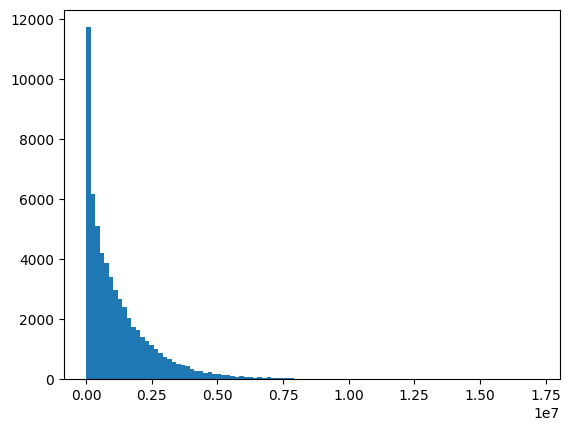

In [21]:
import matplotlib.pyplot as plt
plt.hist(y_ltv, bins=100)

In [22]:
df.corr(numeric_only=True)["target_ltv"].sort_values(ascending=False).head(20)

target_ltv               1.000000
fin_asset_trend_score    0.052085
age                      0.029168
amount_per_active_day    0.013952
amount_per_txn           0.013556
txn_amount_mean          0.013149
txn_amount_sum           0.012182
all_month_amount_sum     0.012182
credit_score             0.011437
deposit_per_card         0.011433
monthly_amount_mean      0.010671
txn_amount_std           0.010509
txn_amount_max           0.010344
deposit_loan_ratio       0.009460
total_deposit_balance    0.008775
is_married               0.006872
txn_per_active_day       0.006712
txn_amount_min           0.006234
monthly_amount_std       0.005671
all_month_count_sum      0.005163
Name: target_ltv, dtype: float64